In [1]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt

print("Open3D:", o3d.__version__)
print("NumPy:", np.__version__)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Open3D: 0.19.0
NumPy: 2.4.6


In [2]:
np.random.seed(42)

In [3]:
mesh = o3d.geometry.TriangleMesh.create_sphere(
    radius=1.0,
    resolution=20
)

mesh.compute_vertex_normals()

clean_vertices = np.asarray(mesh.vertices).copy()
clean_triangles = np.asarray(mesh.triangles).copy()

print("Vertices:", len(clean_vertices))
print("Triangles:", len(clean_triangles))

Vertices: 762
Triangles: 1520


In [4]:
o3d.visualization.draw_plotly(
    [mesh]
)

In [5]:
print("First 5 vertices:")
print(clean_vertices[:5])

print("\nFirst 5 triangles:")
print(clean_triangles[:5])

First 5 vertices:
[[ 0.          0.          1.        ]
 [ 0.          0.         -1.        ]
 [ 0.15643447  0.          0.98768834]
 [ 0.1545085   0.02447174  0.98768834]
 [ 0.14877802  0.04834091  0.98768834]]

First 5 triangles:
[[  0   2   3]
 [  1 723 722]
 [  0   3   4]
 [  1 724 723]
 [  0   4   5]]


In [6]:
noise = np.random.normal(
    loc=0,
    scale=0.05,
    size=clean_vertices.shape
)

noisy_vertices = clean_vertices + noise

print("Noise shape:", noise.shape)
print("First noise vector:", noise[0])

Noise shape: (762, 3)
First noise vector: [ 0.02483571 -0.00691322  0.03238443]


In [7]:
noisy_mesh = o3d.geometry.TriangleMesh()

noisy_mesh.vertices = o3d.utility.Vector3dVector(noisy_vertices)
noisy_mesh.triangles = o3d.utility.Vector3iVector(clean_triangles)

noisy_mesh.compute_vertex_normals()

TriangleMesh with 762 points and 1520 triangles.

In [8]:
o3d.visualization.draw_plotly(
    [noisy_mesh]
)

In [9]:
noisy_error = np.linalg.norm(
    noisy_vertices - clean_vertices,
    axis=1
)

print("Mean noisy error:", noisy_error.mean())
print("Maximum noisy error:", noisy_error.max())

Mean noisy error: 0.07853260931684036
Maximum noisy error: 0.19698874455608964


In [10]:
neighbors = [set() for _ in range(len(noisy_vertices))]

for triangle in clean_triangles:
    a, b, c = triangle

    neighbors[a].update([b, c])
    neighbors[b].update([a, c])
    neighbors[c].update([a, b])

In [11]:
i = 0

print("Vertex:", i)
print("Position:", noisy_vertices[i])
print("Neighbors:", neighbors[i])
print("Number of neighbors:", len(neighbors[i]))

Vertex: 0
Position: [ 0.02483571 -0.00691322  1.03238443]
Neighbors: {np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31), np.int32(32), np.int32(33), np.int32(34), np.int32(35), np.int32(36), np.int32(37), np.int32(38), np.int32(39), np.int32(40), np.int32(41)}
Number of neighbors: 40


In [12]:
i = 0

neighbor_indices = list(neighbors[i])

neighbor_positions = noisy_vertices[neighbor_indices]

neighbor_average = neighbor_positions.mean(axis=0)

print("Current vertex:")
print(noisy_vertices[i])

print("\nNeighbor average:")
print(neighbor_average)
laplacian = neighbor_average - noisy_vertices[i]

print("Laplacian vector:")
print(laplacian)

Current vertex:
[ 0.02483571 -0.00691322  1.03238443]

Neighbor average:
[-0.00549467 -0.0015326   0.98358903]
Laplacian vector:
[-0.03033038  0.00538062 -0.04879539]


In [13]:
lambda_ = 0.5

new_position = (
    noisy_vertices[i]
    + lambda_ * laplacian
)

print("Old position:")
print(noisy_vertices[i])

print("\nNew position:")
print(new_position)

Old position:
[ 0.02483571 -0.00691322  1.03238443]

New position:
[ 0.00967052 -0.00422291  1.00798673]


In [14]:
def laplacian_smooth(vertices, neighbors, lambda_=0.5, iterations=1):

    vertices = vertices.copy()

    for _ in range(iterations):

        new_vertices = vertices.copy()

        for i in range(len(vertices)):

            neighbor_indices = list(neighbors[i])

            if len(neighbor_indices) == 0:
                continue

            neighbor_average = vertices[neighbor_indices].mean(axis=0)

            new_vertices[i] = (
                vertices[i]
                + lambda_ * (neighbor_average - vertices[i])
            )

        vertices = new_vertices

    return vertices

In [15]:
laplacian_vertices_1 = laplacian_smooth(
    noisy_vertices,
    neighbors,
    lambda_=0.5,
    iterations=1
)
laplacian_mesh_1 = o3d.geometry.TriangleMesh()

laplacian_mesh_1.vertices = o3d.utility.Vector3dVector(
    laplacian_vertices_1
)

laplacian_mesh_1.triangles = o3d.utility.Vector3iVector(
    clean_triangles
)

laplacian_mesh_1.compute_vertex_normals()

TriangleMesh with 762 points and 1520 triangles.

In [16]:
o3d.visualization.draw_plotly(
    [laplacian_mesh_1],
    mesh_show_wireframe=True
)

In [17]:
iterations_list = [1, 5, 10, 20, 50]

for iterations in iterations_list:

    smoothed_vertices = laplacian_smooth(
        noisy_vertices,
        neighbors,
        lambda_=0.5,
        iterations=iterations
    )

    smoothed_mesh = o3d.geometry.TriangleMesh()

    smoothed_mesh.vertices = o3d.utility.Vector3dVector(
        smoothed_vertices
    )

    smoothed_mesh.triangles = o3d.utility.Vector3iVector(
        clean_triangles
    )

    smoothed_mesh.compute_vertex_normals()

    print(f"Iterations: {iterations}")

    o3d.visualization.draw_plotly(
        [smoothed_mesh],
        mesh_show_wireframe=True
    )

In [18]:
results = []

for iterations in iterations_list:

    smoothed_vertices = laplacian_smooth(
        noisy_vertices,
        neighbors,
        lambda_=0.5,
        iterations=iterations
    )

    error = np.linalg.norm(
        smoothed_vertices - clean_vertices,
        axis=1
    )

    results.append({
        "iterations": iterations,
        "mean_error": error.mean(),
        "max_error": error.max()
    })

results

[{'iterations': 1,
  'mean_error': np.float64(0.04390894677601054),
  'max_error': np.float64(0.11074888111724965)},
 {'iterations': 5,
  'mean_error': np.float64(0.0430356512478851),
  'max_error': np.float64(0.08207535834248435)},
 {'iterations': 10,
  'mean_error': np.float64(0.07192869168249204),
  'max_error': np.float64(0.10027693255592847)},
 {'iterations': 20,
  'mean_error': np.float64(0.12834139295798955),
  'max_error': np.float64(0.16356826670559435)},
 {'iterations': 50,
  'mean_error': np.float64(0.27157773346312336),
  'max_error': np.float64(0.33054529009651434)}]

In [19]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,iterations,mean_error,max_error
0,1,0.043909,0.110749
1,5,0.043036,0.082075
2,10,0.071929,0.100277
3,20,0.128341,0.163568
4,50,0.271578,0.330545


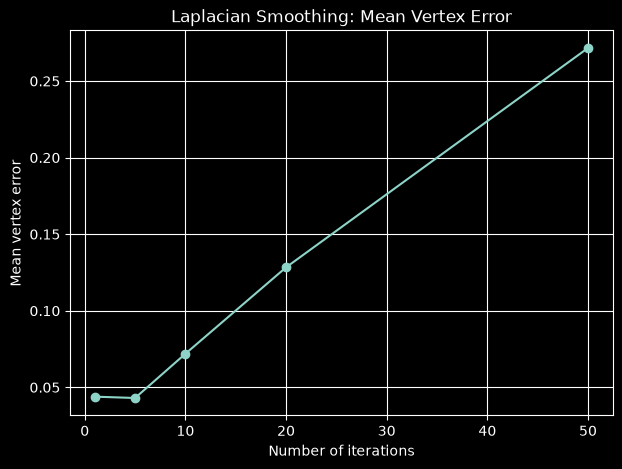

In [20]:
plt.figure(figsize=(7, 5))

plt.plot(
    results_df["iterations"],
    results_df["mean_error"],
    marker="o"
)

plt.xlabel("Number of iterations")
plt.ylabel("Mean vertex error")
plt.title("Laplacian Smoothing: Mean Vertex Error")
plt.grid(True)

plt.show()

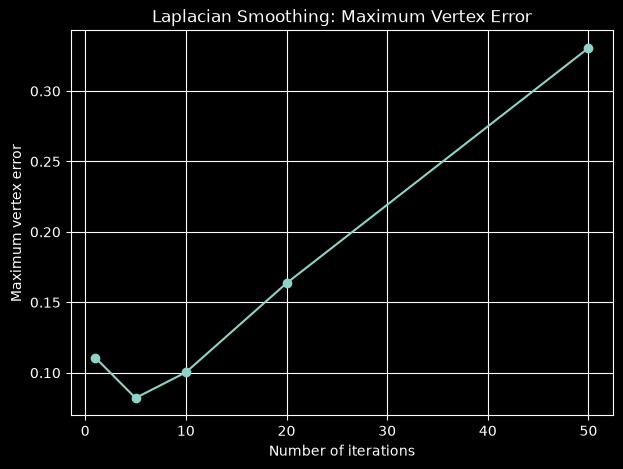

In [21]:
plt.figure(figsize=(7, 5))

plt.plot(
    results_df["iterations"],
    results_df["max_error"],
    marker="o"
)

plt.xlabel("Number of iterations")
plt.ylabel("Maximum vertex error")
plt.title("Laplacian Smoothing: Maximum Vertex Error")
plt.grid(True)

plt.show()

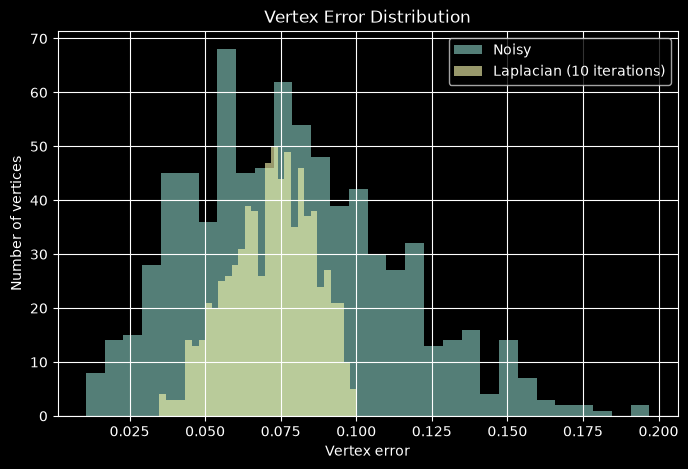

In [22]:
laplacian_vertices_10 = laplacian_smooth(
    noisy_vertices,
    neighbors,
    lambda_=0.5,
    iterations=10
)

laplacian_error_10 = np.linalg.norm(
    laplacian_vertices_10 - clean_vertices,
    axis=1
)
plt.figure(figsize=(8, 5))

plt.hist(
    noisy_error,
    bins=30,
    alpha=0.6,
    label="Noisy"
)

plt.hist(
    laplacian_error_10,
    bins=30,
    alpha=0.6,
    label="Laplacian (10 iterations)"
)

plt.xlabel("Vertex error")
plt.ylabel("Number of vertices")
plt.title("Vertex Error Distribution")

plt.legend()
plt.grid(True)

plt.show()

In [23]:
laplacian_vertices = laplacian_smooth(
    noisy_vertices,
    neighbors,
    lambda_=0.5,
    iterations=10
)

laplacian_mesh = o3d.geometry.TriangleMesh()

laplacian_mesh.vertices = o3d.utility.Vector3dVector(
    laplacian_vertices
)

laplacian_mesh.triangles = o3d.utility.Vector3iVector(
    clean_triangles
)

laplacian_mesh.compute_vertex_normals()
print("Clean mesh")
o3d.visualization.draw_plotly(
    [mesh],
    mesh_show_wireframe=True
)

print("Noisy mesh")
o3d.visualization.draw_plotly(
    [noisy_mesh],
    mesh_show_wireframe=True
)

print("Laplacian smoothed mesh")
o3d.visualization.draw_plotly(
    [laplacian_mesh],
    mesh_show_wireframe=True
)

In [25]:
clean_error = np.zeros(len(clean_vertices))

noisy_error = np.linalg.norm(
    noisy_vertices - clean_vertices,
    axis=1
)

laplacian_error = np.linalg.norm(
    laplacian_vertices - clean_vertices,
    axis=1
)

print(f"Clean mean error:      {clean_error.mean():.6f}")
print(f"Noisy mean error:      {noisy_error.mean():.6f}")
print(f"Laplacian mean error:  {laplacian_error.mean():.6f}")

print()

print(f"Clean max error:       {clean_error.max():.6f}")
print(f"Noisy max error:       {noisy_error.max():.6f}")
print(f"Laplacian max error:   {laplacian_error.max():.6f}")

Clean mean error:      0.000000
Noisy mean error:      0.078533
Laplacian mean error:  0.071929

Clean max error:       0.000000
Noisy max error:       0.196989
Laplacian max error:   0.100277
